In [3]:
import seaborn as sns
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

Path("diagrams").mkdir(exist_ok=True)

In [4]:
result_path = Path("../results/downstream_task")
# bias_types = ["less_negative_class", "less_positive_class", "mean_difference"]
bias_types = ["less_positive_class"]
less_bias_strengths = ["0.1"]
mean_bias_strengthts = ["0.8"]
method_name_replacer = {"mrs-forest": "MRS",  
                        #"fw-mrs-temperature-svm": "FW-MRS-SVM",
                        "fw-mrs-temperature": "FW-MRS",
                        "fw-mrs-temperature-negative": "FW-MRS$_{Neg}$",
                        }
data_set_replacer = {"folktables_employment": "Employment", "folktables_income": "Income",
                               "breast_cancer": "Breast Cancer", "hr_analytics": "HR Analytic", "loan_prediction": "Loan",
                               "diabetes": "Diabetes", "german_credit": "German Credit", "bank_marketing": "Bank Marketing"}

## Plot per temperature

In [5]:
dict_list = []
auroc_dict_list = []

for dataset in data_set_replacer.keys():
    for bias_type in bias_types:
        for method in ("fw-mrs-temperature", "fw-mrs-temperature-negative"):
            if bias_type == "mean_difference":
                bias_strengths = mean_bias_strengthts
            else : 
                bias_strengths = less_bias_strengths
            for bias_strength in bias_strengths:
                dropped_samples_file_name = result_path / dataset / bias_type /  bias_strength/ method / "validation/dropped_samples_val_dict.json"
                try:
                    dropped_samples_file = pd.read_json(str(dropped_samples_file_name), orient="records", typ="series", convert_axes=False)
                except FileNotFoundError:
                    continue
                auroc_file_name = result_path / dataset / bias_type /  bias_strength/ method / "validation"/ "auroc_val_dict.json"
                auroc_file = pd.read_json(str(auroc_file_name), orient="records", typ="series", convert_axes=False)
                dict_list.append(
                    {
                        "Dropped Samples": dropped_samples_file,
                        "Data Set": dataset,
                        "Method": method,
                        "bias_type": bias_type,
                        "bias_strength": bias_strength,
                    }
                                )
                auroc_dict_list.append(
                    {
                        "AUROC": auroc_file
                }
                )

result_df = pd.DataFrame(data=dict_list)
auroc_result_df = pd.DataFrame(data=auroc_dict_list)
result_df = pd.concat([result_df.drop(['Dropped Samples'], axis=1),result_df["Dropped Samples"].apply(pd.Series)], axis=1)

temperatures = list(result_df.columns.drop(["Data Set", "Method", "bias_type", "bias_strength"]))

result_df = result_df.explode(temperatures)
result_df = result_df.melt(var_name="Temperature", value_name="Dropped Samples", value_vars=temperatures, 
                        id_vars=result_df.drop(columns=temperatures).columns)
auroc_result_df = pd.concat([auroc_result_df.drop(['AUROC'], axis=1), auroc_result_df["AUROC"].apply(pd.Series)], axis=1)
auroc_result_df = auroc_result_df.explode(temperatures)
auroc_result_df = auroc_result_df.melt(var_name="Temperature", value_name="AUROC", value_vars=temperatures)

result_df = pd.concat([result_df, auroc_result_df["AUROC"]], axis=1)

ValueError: columns must have matching element counts

In [ ]:
result_df

,Data Set,Method,bias_type,bias_strength,0.01,0.05,0.1,-0.01,-0.05,-0.1
0,folktables_employment,fw-mrs-temperature,less_positive_class,0.1,"[315, 280, 315, 280, 365, 325, 335, 310, 265, ...","[455, 355, 390, 300, 460, 440, 400, 420, 400, ...","[440, 350, 410, 355, 465, 420, 405, 430, 405, ...",NaN,NaN,NaN
1,folktables_employment,fw-mrs-temperature-negative,less_positive_class,0.1,NaN,NaN,NaN,"[525, 440, 435, 365, 490, 480, 450, 460, 455, ...","[350, 255, 290, 130, 535, 340, 290, 265, 450, ...","[465, 175, 205, 230, 195, 230, 180, 250, 290, ..."
2,folktables_income,fw-mrs-temperature,less_positive_class,0.1,"[285, 285, 345, 260, 260, 285, 310, 275, 290, ...","[380, 345, 395, 285, 290, 345, 330, 355, 345, ...","[360, 330, 390, 240, 95, 190, 350, 165, 170, 2...",NaN,NaN,NaN
3,folktables_income,fw-mrs-temperature-negative,less_positive_class,0.1,NaN,NaN,NaN,"[410, 345, 380, 300, 300, 340, 315, 360, 370, ...","[400, 170, 175, 195, 205, 270, 345, 345, 375, ...","[205, 235, 370, 310, 300, 270, 325, 330, 235, ..."
4,breast_cancer,fw-mrs-temperature,less_positive_class,0.1,"[41, 31, 56, 52, 54, 50, 56, 58, 56, 50, 51, 5...","[51, 55, 58, 55, 52, 59, 59, 62, 61, 57, 55, 6...","[52, 56, 55, 56, 56, 58, 56, 47, 61, 59, 51, 6...",NaN,NaN,NaN
5,breast_cancer,fw-mrs-temperature-negative,less_positive_class,0.1,NaN,NaN,NaN,"[53, 45, 59, 53, 54, 63, 57, 58, 36, 45, 59, 5...","[52, 52, 51, 56, 57, 59, 59, 55, 60, 64, 57, 5...","[54, 50, 61, 57, 53, 59, 62, 48, 60, 52, 58, 6..."
6,hr_analytics,fw-mrs-temperature,less_positive_class,0.1,"[45, 115, 50, 160, 100, 25, 105, 10, 10, 30, 7...","[50, 155, 70, 220, 125, 125, 190, 70, 60, 85, ...","[45, 180, 95, 90, 55, 80, 175, 65, 90, 65, 190...",NaN,NaN,NaN
7,hr_analytics,fw-mrs-temperature-negative,less_positive_class,0.1,NaN,NaN,NaN,"[100, 135, 110, 240, 120, 65, 50, 80, 110, 155...","[115, 145, 90, 70, 95, 110, 175, 80, 130, 120,...","[120, 170, 120, 180, 45, 100, 165, 55, 60, 160..."
8,loan_prediction,fw-mrs-temperature,less_positive_class,0.1,"[0, 0, 0, 0, 0, 1, 6, 0, 0, 7, 0, 7, 6, 6, 0, ...","[1, 1, 5, 1, 0, 7, 3, 1, 2, 10, 1, 20, 4, 5, 7...","[0, 6, 4, 0, 1, 10, 9, 3, 0, 11, 5, 21, 4, 6, ...",NaN,NaN,NaN
9,loan_prediction,fw-mrs-temperature-negative,less_positive_class,0.1,NaN,NaN,NaN,"[1, 13, 7, 8, 1, 19, 3, 9, 5, 7, 12, 16, 8, 12...","[0, 13, 9, 8, 1, 17, 10, 6, 1, 11, 4, 24, 5, 7...","[3, 13, 10, 6, 0, 14, 10, 1, 5, 12, 4, 24, 10,..."


## Load MRS

In [8]:
mrs_dict_list = []
mrs_auroc_dict_list = []

for dataset in data_set_replacer.keys():
    for bias_type in bias_types:
        if bias_type == "mean_difference":
            bias_strengths = mean_bias_strengthts
        else : 
            bias_strengths = less_bias_strengths
        for bias_strength in bias_strengths:
            dropped_samples_file_name = result_path / dataset / bias_type /  bias_strength/ "mrs-forest" / "validation" / "dropped_samples_individual_val_dict.json"
            auroc_file_name = result_path / dataset / bias_type /  bias_strength/ "mrs-forest" / "validation"/ "auroc_individual_val_dict.json"
            try:
                dropped_samples_file = pd.read_json(str(dropped_samples_file_name), orient="records", typ="series", convert_axes=False)
            except FileNotFoundError:
                    continue
            auroc_file = pd.read_json(str(auroc_file_name), orient="records", typ="series", convert_axes=False)
            mrs_dict_list.append(
                {
                    "Dropped Samples": dropped_samples_file["0.0"]["0.01"],
                    "Data Set": dataset,
                    "Method": "MRS",
                    "bias_type": bias_type,
                    "bias_strength": bias_strength,
                }
                            )
            mrs_auroc_dict_list.extend(auroc_file["0.0"]["0.01"])
mrs_result_df = pd.DataFrame(data=mrs_dict_list)
mrs_result_df = mrs_result_df.explode("Dropped Samples")
mrs_result_df["Temperature"] = "MRS"
mrs_result_df["AUROC"] = mrs_auroc_dict_list

In [ ]:
result_df = pd.concat([result_df, mrs_result_df], axis=0)

In [ ]:
result_df["Dropped Samples"] = result_df["Dropped Samples"].astype(float)
result_df = result_df.replace(method_name_replacer)
result_df = result_df.replace(data_set_replacer)
result_df.loc[result_df["Data Set"] == "Employment", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Employment", "Dropped Samples"] / 1408)
result_df.loc[result_df["Data Set"] == "Income", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Income", "Dropped Samples"] / 1448)
result_df.loc[result_df["Data Set"] == "HR Analytic", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "HR Analytic", "Dropped Samples"] / 3048)
result_df.loc[result_df["Data Set"] == "Breast Cancer", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Breast Cancer", "Dropped Samples"] / 113)
result_df.loc[result_df["Data Set"] == "Loan", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Loan", "Dropped Samples"] / 72)

result_df.loc[result_df["Data Set"] == "German Credit", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "German Credit", "Dropped Samples"] / 292)
result_df.loc[result_df["Data Set"] == "Diabetes", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Diabetes", "Dropped Samples"] / 2108)
result_df.loc[result_df["Data Set"] == "Bank Marketing", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Bank Marketing", "Dropped Samples"] / 2150)

## With AUROC

In [ ]:
hue_order = ["MRS"] + temperatures

ValueError: cannot reindex on an axis with duplicate labels

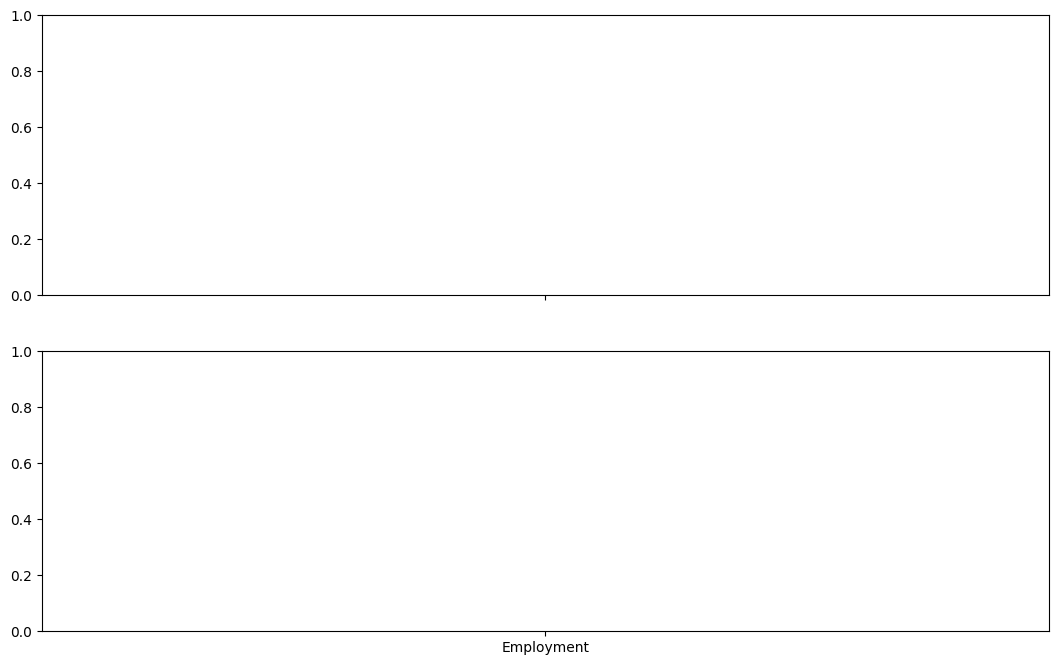

In [ ]:
fig, axes = plt.subplots(2, 1, sharey=False, sharex=True, figsize=(13, 8))
ylabel="Relative Dropped Samples (%)"
sns.set_theme(style="ticks", palette="colorblind")
sns.boxplot(data=result_df[result_df["Method"].isin(["MRS", "FW-MRS", "FW-MRS$_{Neg}$"])], y="Dropped Samples", x="Data Set", 
            hue="Temperature", legend=True, hue_order=hue_order,
              ax=axes[0]).set(ylabel=ylabel)

sns.boxplot(data=result_df[result_df["Method"].isin(["MRS", "FW-MRS", "FW-MRS$_{Neg}$"])], y="AUROC", x="Data Set", 
            hue="Temperature", legend=True, hue_order=hue_order,
              ax=axes[1]).set(ylabel="AUROC")

# sns.boxplot(data=result_df[result_df["Method"].isin(["MRS", "FW-MRS-SVM"])], y="Dropped Samples", x="Data Set", 
#           hue="Temperature", ax=axes[1], hue_order=hue_order).set(xlabel="(b) FW-MRS-SVM", ylabel=None)
#fig.text(0.08,0.5, ylabel, ha="center", va="center", rotation=90)
plt.savefig("diagrams/dropped_samples_per_temperature_fixed.pdf")

In [ ]:
#fig, axes = plt.subplots(1, 1, sharey=True, sharex=False, figsize=(12, 4))
#ylabel="AUROC"
#sns.set_theme(style="ticks", palette="colorblind")
#sns.boxplot(data=result_df[result_df["Method"].isin(["MRS", "FW-MRS"])], y="AUROC", x="Data Set", 
#            hue="Temperature", legend=True, hue_order=hue_order,
#              ax=axes).set(ylabel=ylabel)
#sns.boxplot(data=result_df[result_df["Method"].isin(["MRS", "FW-MRS-SVM"])], y="AUROC", x="Data Set", 
#           hue="Temperature", ax=axes[1], hue_order=hue_order).set(xlabel="(b) FW-MRS-SVM", ylabel=None)
#fig.text(0.05,0.5, ylabel, ha="center", va="center", rotation=90)
#plt.savefig("diagrams/auroc_per_temperature_fixed.pdf")

## Plot per method

In [9]:
aurocs = []
auprcs = []
dict_list = []
auroc_dict_list = []
for dataset in data_set_replacer.keys():
    for bias_type in bias_types:
        for method in method_name_replacer.keys():
            if bias_type == "mean_difference":
                bias_strengths = mean_bias_strengthts
            else : 
                bias_strengths = less_bias_strengths
            for bias_strength in bias_strengths:
                dropped_samples_file = result_path / dataset / bias_type /  bias_strength/ method / "classification_results" / "dropped_samples.json"
                auroc_file_name = result_path / dataset / bias_type /  bias_strength/ method / "classification_results"/ "rf_auroc.json"
                try:
                    dropped_samples_file = pd.read_json(str(dropped_samples_file), typ="series")
                    auroc_file = pd.read_json(str(auroc_file_name), orient="records", typ="series", convert_axes=False)
                except FileNotFoundError:
                    continue
                dict_list.append(
                    {
                        "Dropped Samples": dropped_samples_file,
                        "Data Set": dataset,
                        "Method": method,
                        "bias_type": bias_type,
                        "bias_strength": bias_strength,
                    }
                                )
                auroc_dict_list.append(
                    {
                        "AUROC": auroc_file
                    }
                                )
result_df = pd.DataFrame(data=dict_list)
auroc_result_df = pd.DataFrame(data=auroc_dict_list)
auroc_result_df = auroc_result_df.explode(column="AUROC", ignore_index=True)
result_df = result_df.explode(column="Dropped Samples", ignore_index=True)
result_df = pd.concat([result_df, auroc_result_df["AUROC"]], axis=1)
result_df = pd.concat([result_df, mrs_result_df], axis=0)
result_df = result_df.replace(method_name_replacer)
result_df = result_df.replace(data_set_replacer)
result_df = result_df.drop(columns=["Temperature"])

/tmp/ipykernel_1923648/1432382030.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  result_df = result_df.replace(method_name_replacer)


In [10]:
result_df["Dropped Samples"] = result_df["Dropped Samples"].astype(float)
result_df.loc[result_df["Data Set"] == "Employment", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Employment", "Dropped Samples"] / 1408)
result_df.loc[result_df["Data Set"] == "Income", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Income", "Dropped Samples"] / 1448)
result_df.loc[result_df["Data Set"] == "HR Analytic", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "HR Analytic", "Dropped Samples"] / 3048)
result_df.loc[result_df["Data Set"] == "Breast Cancer", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Breast Cancer", "Dropped Samples"] / 113)
result_df.loc[result_df["Data Set"] == "Loan", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Loan", "Dropped Samples"] / 72)

result_df.loc[result_df["Data Set"] == "German Credit", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "German Credit", "Dropped Samples"] / 292)
result_df.loc[result_df["Data Set"] == "Diabetes", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Diabetes", "Dropped Samples"] / 2108)
result_df.loc[result_df["Data Set"] == "Bank Marketing", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Bank Marketing", "Dropped Samples"] / 2150)

## Test Results

In [11]:
data_set_order = ["Employment", "Income", "HR Analytic", "Breast Cancer", "Loan", "Diabetes", "German Credit", "Bank Marketing"]

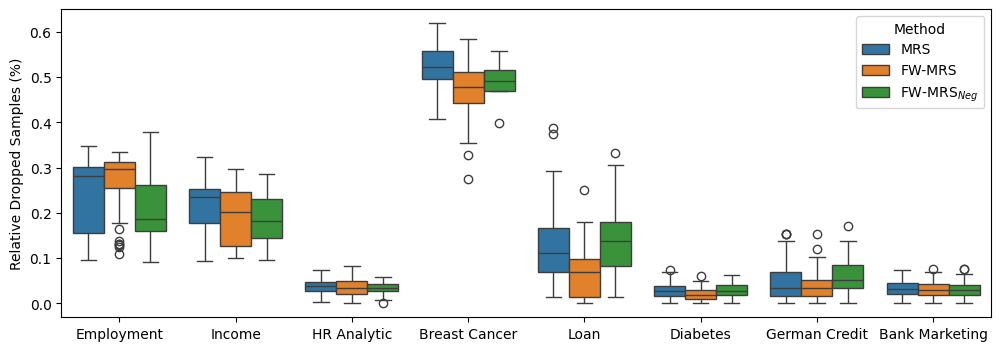

In [12]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=result_df, y="Dropped Samples", x="Data Set", hue="Method",
            order=data_set_order,
            hue_order=method_name_replacer.values()).set(xlabel=None, ylabel="Relative Dropped Samples (%)")
plt.savefig("diagrams/relative_dropped_samples_per_method_complete.pdf", bbox_inches="tight")

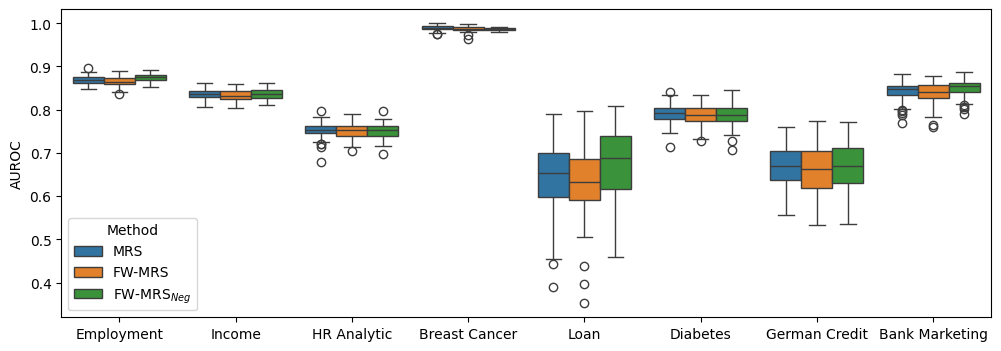

In [13]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=result_df, y="AUROC", x="Data Set", hue="Method",
            order=data_set_order,
            hue_order=method_name_replacer.values()).set(xlabel=None, ylabel="AUROC")
plt.savefig("diagrams/auroc_samples_per_method_complete.pdf", bbox_inches="tight")